In [1]:
# Import all required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")

✅ All libraries imported successfully!
Pandas version: 3.0.2


In [2]:
# Load the dataset
df = pd.read_csv('galamsay_data - galamsay_data.csv')

# Display first 10 rows
print("✅ Dataset loaded successfully!")
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nColumn names: {list(df.columns)}")
print("\n--- First 10 rows ---")
df.head(10)

✅ Dataset loaded successfully!
Total rows: 96
Total columns: 3

Column names: ['City', 'Region', 'Number_of_Galamsay_Sites']

--- First 10 rows ---


,City,Region,Number_of_Galamsay_Sites
0,Obuasi,Ashanti,15
1,Tarkwa,Western,10
2,Prestea,Western,8
3,Konongo,Ashanti,12
4,Bolgatanga,Upper East,5
5,Kumasi,Ashanti,25
6,Takoradi,Western,18
7,Accra,Greater Accra,30
8,Tamale,Northern,7
9,Cape Coast,Central,14


In [3]:
# Explore the dataset
print("=== DATASET INFORMATION ===")
print(df.info())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== UNIQUE VALUES PER COLUMN ===")
print(f"Unique Cities: {df['City'].nunique()}")
print(f"Unique Regions: {df['Region'].nunique()}")
print(f"Unique Site Counts: {df['Number_of_Galamsay_Sites'].nunique()}")

print("\n=== ALL UNIQUE REGIONS ===")
print(df['Region'].unique())

print("\n=== SAMPLE OF PROBLEMATIC VALUES ===")
print(df['Number_of_Galamsay_Sites'].unique())

=== DATASET INFORMATION ===
<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   City                      95 non-null     str  
 1   Region                    95 non-null     str  
 2   Number_of_Galamsay_Sites  96 non-null     str  
dtypes: str(3)
memory usage: 2.4 KB
None

=== MISSING VALUES ===
City                        1
Region                      1
Number_of_Galamsay_Sites    0
dtype: int64

=== UNIQUE VALUES PER COLUMN ===
Unique Cities: 51
Unique Regions: 13
Unique Site Counts: 24

=== ALL UNIQUE REGIONS ===
<StringArray>
[       'Ashanti',        'Western',     'Upper East',  'Greater Accra',
       'Northern',        'Central',           'Bono',     'Upper West',
          'Volta',        'Eastern',      'Bono East',       'Savannah',
              nan, 'Invalid Region']
Length: 14, dtype: str

=== SAMPLE OF PROBLEMATIC VALUES

In [ ]:
# ============================================
# DATA CLEANING
# ============================================

print("=== BEFORE CLEANING ===")
print(f"Total rows: {len(df)}")

# Step 1: Fix text values in Number_of_Galamsay_Sites
# Replace 'eleven' with 11 and 'abc' with NaN
df['Number_of_Galamsay_Sites'] = df['Number_of_Galamsay_Sites'].replace('eleven', '11')
df['Number_of_Galamsay_Sites'] = df['Number_of_Galamsay_Sites'].replace('abc', None)

# Step 2: Convert to numeric
df['Number_of_Galamsay_Sites'] = pd.to_numeric(
    df['Number_of_Galamsay_Sites'], errors='coerce')

# Step 3: Remove negative values
df = df[df['Number_of_Galamsay_Sites'] >= 0]

# Step 4: Remove extreme outliers (Sunyani 1000)
df = df[df['Number_of_Galamsay_Sites'] <= 500]

# Step 5: Remove rows with missing City or Region
df = df.dropna(subset=['City', 'Region'])

# Step 6: Remove Invalid Region
df = df[df['Region'] != 'Invalid Region']
# Step 7: Remove duplicate rows
df = df.drop_duplicates()

# Step 8: Reset index
df = df.reset_index(drop=True)

print("\n=== AFTER CLEANING ===")
print(f"Total rows remaining: {len(df)}")
print(f"\nMissing values after cleaning:")
print(df.isnull().sum())
print(f"\nRegions remaining: {df['Region'].unique()}")
print("\n✅ Data cleaning complete!")

=== BEFORE CLEANING ===
Total rows: 96

=== AFTER CLEANING ===
Total rows remaining: 51

Missing values after cleaning:
City                        0
Region                      0
Number_of_Galamsay_Sites    0
dtype: int64

Regions remaining: <StringArray>
[      'Ashanti',       'Western',    'Upper East', 'Greater Accra',
      'Northern',       'Central',          'Bono',    'Upper West',
         'Volta',       'Eastern',     'Bono East',      'Savannah']
Length: 12, dtype: str

✅ Data cleaning complete!


In [5]:
# ============================================
# KEY STATISTICS & ANALYSIS
# ============================================

# Total sites
total_sites = df['Number_of_Galamsay_Sites'].sum()

# Average sites per region
avg_per_region = df.groupby('Region')['Number_of_Galamsay_Sites'].sum().mean()

# Region with highest sites
region_totals = df.groupby('Region')['Number_of_Galamsay_Sites'].sum().sort_values(ascending=False)
top_region = region_totals.index[0]
top_region_sites = region_totals.iloc[0]

# Top city
top_city = df.loc[df['Number_of_Galamsay_Sites'].idxmax(), 'City']
top_city_sites = df['Number_of_Galamsay_Sites'].max()

# Cities above threshold (more than 10 sites)
high_risk_cities = df[df['Number_of_Galamsay_Sites'] > 10]

print("=" * 50)
print("   GALAMSEY MONITORING — KEY STATISTICS")
print("=" * 50)
print(f"\n📊 Total Galamsey Sites:        {total_sites}")
print(f"🏙️  Total Cities Analysed:       {len(df)}")
print(f"🗺️  Total Regions:               {df['Region'].nunique()}")
print(f"📈 Average Sites per Region:    {avg_per_region:.2f}")
print(f"\n🔴 Top Region (Highest Risk):   {top_region} ({top_region_sites} sites)")
print(f"🏆 Top City (Highest Sites):    {top_city} ({top_city_sites} sites)")
print(f"\n⚠️  Cities Exceeding 10 Sites:  {len(high_risk_cities)} cities")
print(f"✅ Cities Below 10 Sites:       {len(df) - len(high_risk_cities)} cities")

print("\n--- REGION SUMMARY TABLE ---")
region_summary = df.groupby('Region').agg(
    Total_Sites=('Number_of_Galamsay_Sites', 'sum'),
    Avg_Sites=('Number_of_Galamsay_Sites', 'mean'),
    City_Count=('City', 'count')
).round(2).sort_values('Total_Sites', ascending=False)
print(region_summary)

   GALAMSEY MONITORING — KEY STATISTICS

📊 Total Galamsey Sites:        660.0
🏙️  Total Cities Analysed:       51
🗺️  Total Regions:               12
📈 Average Sites per Region:    55.00

🔴 Top Region (Highest Risk):   Ashanti (134.0 sites)
🏆 Top City (Highest Sites):    Accra (30.0 sites)

⚠️  Cities Exceeding 10 Sites:  29 cities
✅ Cities Below 10 Sites:       22 cities

--- REGION SUMMARY TABLE ---
               Total_Sites  Avg_Sites  City_Count
Region                                           
Ashanti              134.0      16.75           8
Greater Accra        127.0      25.40           5
Western              109.0      13.62           8
Central               89.0      12.71           7
Eastern               56.0       9.33           6
Volta                 43.0      10.75           4
Bono East             27.0      13.50           2
Bono                  21.0      10.50           2
Savannah              21.0       7.00           3
Northern              18.0       6.00        

In [6]:
# ============================================
# RISK CLASSIFICATION
# ============================================

# Classify each city into risk levels
def classify_risk(sites):
    if sites >= 20:
        return '🔴 High Risk'
    elif sites >= 10:
        return '🟡 Medium Risk'
    else:
        return '🟢 Low Risk'

# Apply classification
df['Risk_Level'] = df['Number_of_Galamsay_Sites'].apply(classify_risk)

# Count by risk level
risk_counts = df['Risk_Level'].value_counts()

print("=" * 50)
print("      CITY RISK CLASSIFICATION")
print("=" * 50)
print(f"\n{risk_counts.to_string()}")

print("\n--- HIGH RISK CITIES (20+ sites) ---")
high_risk = df[df['Number_of_Galamsay_Sites'] >= 20][
    ['City', 'Region', 'Number_of_Galamsay_Sites', 'Risk_Level']
].sort_values('Number_of_Galamsay_Sites', ascending=False)
print(high_risk.to_string(index=False))

print("\n--- MEDIUM RISK CITIES (10-19 sites) ---")
medium_risk = df[(df['Number_of_Galamsay_Sites'] >= 10) &
                 (df['Number_of_Galamsay_Sites'] < 20)][
    ['City', 'Region', 'Number_of_Galamsay_Sites', 'Risk_Level']
].sort_values('Number_of_Galamsay_Sites', ascending=False)
print(medium_risk.to_string(index=False))

print("\n✅ Risk classification complete!")

      CITY RISK CLASSIFICATION

Risk_Level
🟡 Medium Risk    25
🟢 Low Risk       18
🔴 High Risk       8

--- HIGH RISK CITIES (20+ sites) ---
    City        Region  Number_of_Galamsay_Sites  Risk_Level
   Accra Greater Accra                      30.0 🔴 High Risk
    Tema Greater Accra                      30.0 🔴 High Risk
  Adenta Greater Accra                      25.0 🔴 High Risk
  Kumasi       Ashanti                      25.0 🔴 High Risk
Ashaiman Greater Accra                      22.0 🔴 High Risk
   Ejura       Ashanti                      22.0 🔴 High Risk
 Sekondi       Western                      20.0 🔴 High Risk
  Madina Greater Accra                      20.0 🔴 High Risk

--- MEDIUM RISK CITIES (10-19 sites) ---
          City    Region  Number_of_Galamsay_Sites    Risk_Level
         Kasoa   Central                      19.0 🟡 Medium Risk
Duayaw Nkwanta   Ashanti                      18.0 🟡 Medium Risk
      Takoradi   Western                      18.0 🟡 Medium Risk
       B

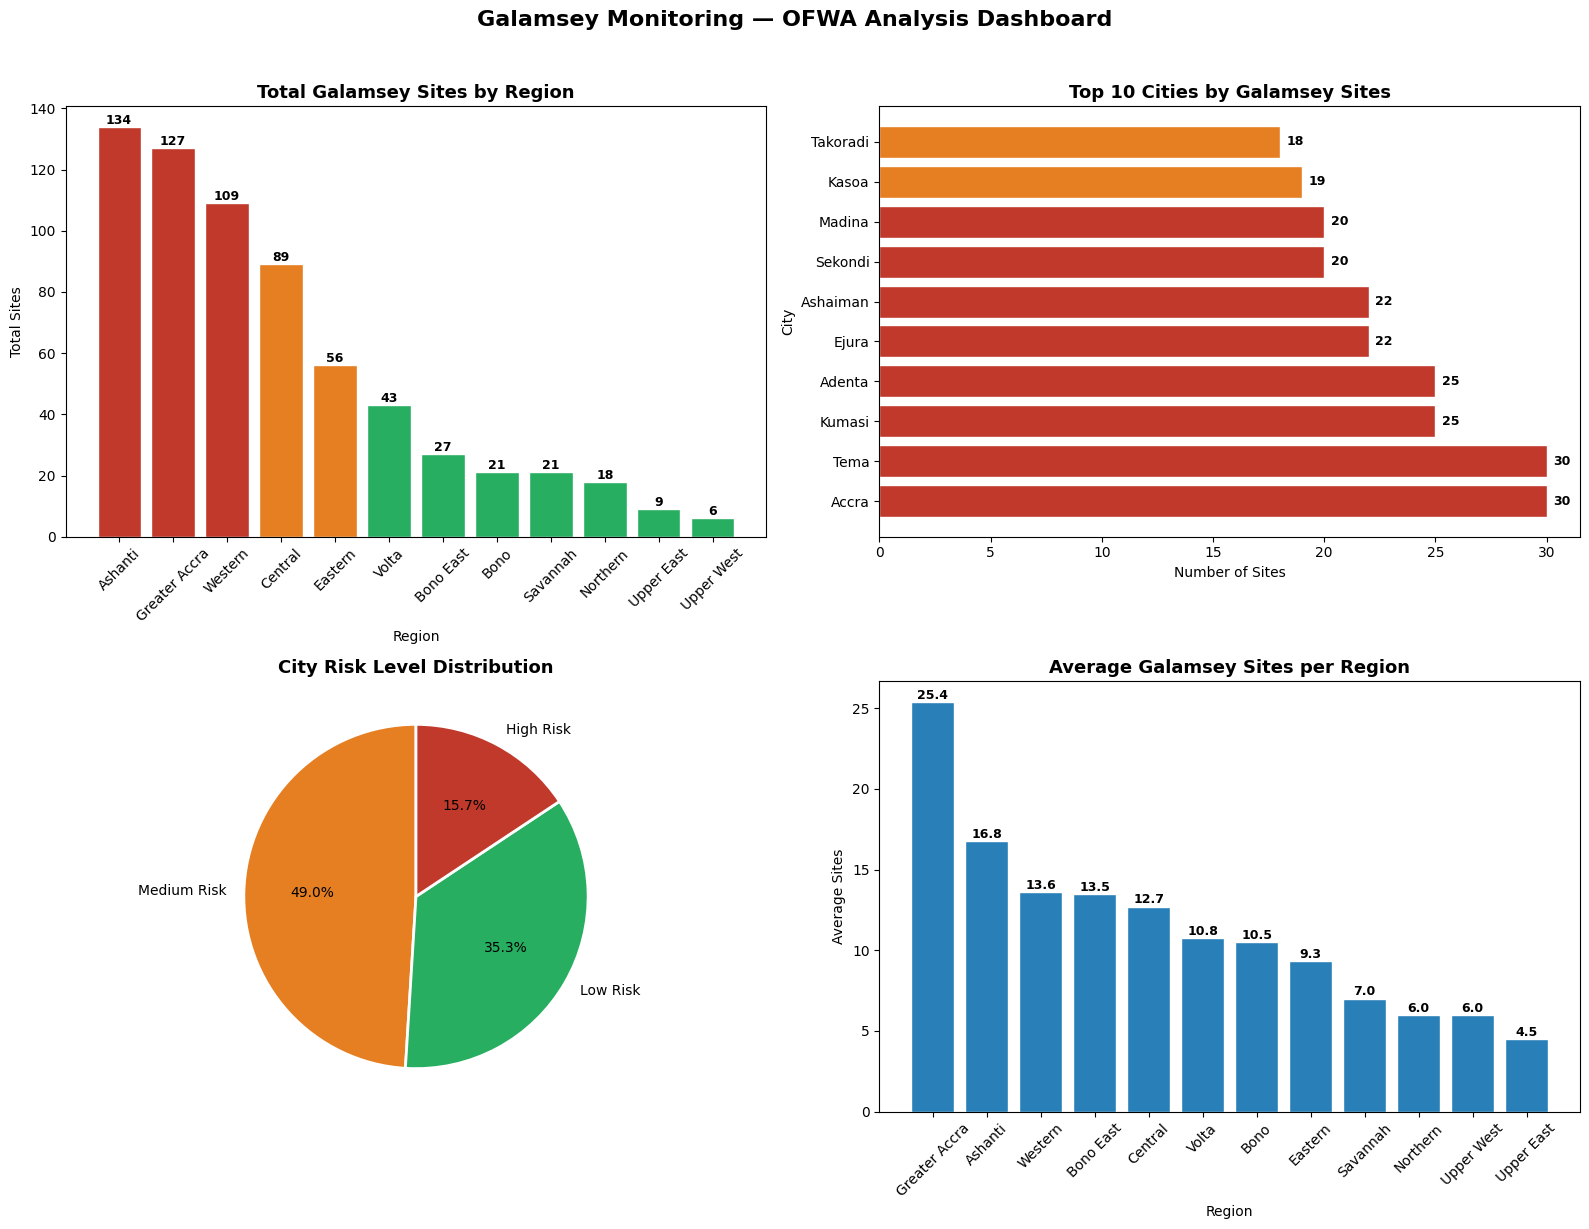


✅ Charts created and saved as galamsey_dashboard.png!


In [7]:
# ============================================
# VISUALISATIONS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Galamsey Monitoring — OFWA Analysis Dashboard',
             fontsize=16, fontweight='bold', y=1.02)

# --- Chart 1: Total Sites by Region (Bar Chart) ---
region_totals = df.groupby('Region')['Number_of_Galamsay_Sites'].sum().sort_values(ascending=False)
colors1 = ['#C0392B' if x >= 100 else '#E67E22' if x >= 50 else '#27AE60'
           for x in region_totals.values]
axes[0,0].bar(region_totals.index, region_totals.values, color=colors1, edgecolor='white')
axes[0,0].set_title('Total Galamsey Sites by Region', fontweight='bold', fontsize=13)
axes[0,0].set_xlabel('Region')
axes[0,0].set_ylabel('Total Sites')
axes[0,0].tick_params(axis='x', rotation=45)
for i, v in enumerate(region_totals.values):
    axes[0,0].text(i, v + 1, str(int(v)), ha='center', fontweight='bold', fontsize=9)

# --- Chart 2: Top 10 Cities (Horizontal Bar Chart) ---
top10_cities = df.nlargest(10, 'Number_of_Galamsay_Sites')
colors2 = ['#C0392B' if x >= 20 else '#E67E22' if x >= 10 else '#27AE60'
           for x in top10_cities['Number_of_Galamsay_Sites']]
axes[0,1].barh(top10_cities['City'], top10_cities['Number_of_Galamsay_Sites'],
               color=colors2, edgecolor='white')
axes[0,1].set_title('Top 10 Cities by Galamsey Sites', fontweight='bold', fontsize=13)
axes[0,1].set_xlabel('Number of Sites')
axes[0,1].set_ylabel('City')
for i, v in enumerate(top10_cities['Number_of_Galamsay_Sites']):
    axes[0,1].text(v + 0.3, i, str(int(v)), va='center', fontweight='bold', fontsize=9)

# --- Chart 3: Risk Level Distribution (Pie Chart) ---
risk_counts = df['Risk_Level'].value_counts()
risk_labels = [r.split(' ', 1)[1] for r in risk_counts.index]
colors3 = ['#E67E22', '#27AE60', '#C0392B']
axes[1,0].pie(risk_counts.values, labels=risk_labels, autopct='%1.1f%%',
              colors=colors3, startangle=90,
              wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1,0].set_title('City Risk Level Distribution', fontweight='bold', fontsize=13)

# --- Chart 4: Average Sites per Region (Bar Chart) ---
avg_sites = df.groupby('Region')['Number_of_Galamsay_Sites'].mean().sort_values(ascending=False)
axes[1,1].bar(avg_sites.index, avg_sites.values, color='#2980B9', edgecolor='white')
axes[1,1].set_title('Average Galamsey Sites per Region', fontweight='bold', fontsize=13)
axes[1,1].set_xlabel('Region')
axes[1,1].set_ylabel('Average Sites')
axes[1,1].tick_params(axis='x', rotation=45)
for i, v in enumerate(avg_sites.values):
    axes[1,1].text(i, v + 0.2, f'{v:.1f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('galamsey_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Charts created and saved as galamsey_dashboard.png!")

In [8]:
# ============================================
# EXPORT RESULTS TO EXCEL
# ============================================

# Create Excel writer
with pd.ExcelWriter('galamsey_analysis_results.xlsx', engine='openpyxl') as writer:

    # Sheet 1 — Cleaned Data
    df.to_excel(writer, sheet_name='Cleaned_Data', index=False)

    # Sheet 2 — Region Summary
    region_summary = df.groupby('Region').agg(
        Total_Sites=('Number_of_Galamsay_Sites', 'sum'),
        Average_Sites=('Number_of_Galamsay_Sites', 'mean'),
        City_Count=('City', 'count')
    ).round(2).sort_values('Total_Sites', ascending=False)
    region_summary.to_excel(writer, sheet_name='Region_Summary')

    # Sheet 3 — High Risk Cities
    high_risk = df[df['Number_of_Galamsay_Sites'] >= 20][
        ['City', 'Region', 'Number_of_Galamsay_Sites', 'Risk_Level']
    ].sort_values('Number_of_Galamsay_Sites', ascending=False)
    high_risk.to_excel(writer, sheet_name='High_Risk_Cities', index=False)

    # Sheet 4 — All Cities with Risk Level
    df[['City', 'Region', 'Number_of_Galamsay_Sites', 'Risk_Level']].sort_values(
        'Number_of_Galamsay_Sites', ascending=False
    ).to_excel(writer, sheet_name='All_Cities_Risk', index=False)

    # Sheet 5 — Key Statistics Summary
    stats = pd.DataFrame({
        'Metric': [
            'Total Galamsey Sites',
            'Total Cities Analysed',
            'Total Regions',
            'Average Sites per Region',
            'Top Region',
            'Top City',
            'High Risk Cities (20+ sites)',
            'Medium Risk Cities (10-19 sites)',
            'Low Risk Cities (below 10 sites)'
        ],
        'Value': [
            660,
            51,
            12,
            55.0,
            'Ashanti (134 sites)',
            'Accra & Tema (30 sites each)',
            8,
            25,
            18
        ]
    })
    stats.to_excel(writer, sheet_name='Key_Statistics', index=False)

print("✅ Excel file saved as: galamsey_analysis_results.xlsx")
print("\n📋 Sheets created:")
print("   1. Cleaned_Data — All 51 clean records")
print("   2. Region_Summary — Totals and averages by region")
print("   3. High_Risk_Cities — 8 cities with 20+ sites")
print("   4. All_Cities_Risk — All cities with risk classification")
print("   5. Key_Statistics — Summary of all key findings")

✅ Excel file saved as: galamsey_analysis_results.xlsx

📋 Sheets created:
   1. Cleaned_Data — All 51 clean records
   2. Region_Summary — Totals and averages by region
   3. High_Risk_Cities — 8 cities with 20+ sites
   4. All_Cities_Risk — All cities with risk classification
   5. Key_Statistics — Summary of all key findings


In [9]:
# ============================================
# BUSINESS INSIGHTS & RECOMMENDATIONS
# ============================================

print("=" * 60)
print("   OFWA GALAMSEY MONITORING — BUSINESS INSIGHTS")
print("=" * 60)

print("""
📊 KEY FINDINGS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Total of 660 galamsey sites identified across 51 cities
   in 12 regions of Ghana.

2. Ashanti Region is the highest risk region with 134 sites
   across 8 cities — requiring urgent intervention.

3. Greater Accra has the highest average sites per city
   (25.4) — meaning urban areas are heavily affected.

4. Accra and Tema are the most affected cities with
   30 sites each — classified as 🔴 HIGH RISK.

5. 8 cities (15.7%) are HIGH RISK with 20+ sites each.
   29 cities (56.9%) exceed the 10-site threshold.

6. Savannah, Northern and Upper East regions show
   lower activity — currently lower priority zones.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 RECOMMENDATIONS FOR OFWA:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. PRIORITY 1 — Immediate Intervention:
   Deploy resources to Accra, Tema, Kumasi and Adenta
   first — these 4 cities alone account for 110 sites.

2. PRIORITY 2 — Regional Monitoring:
   Ashanti and Greater Accra regions need dedicated
   monitoring teams due to highest concentration of sites.

3. PRIORITY 3 — Threshold Alert System:
   Set automatic alerts for any city crossing 10 sites.
   Currently 29 cities exceed this threshold.

4. RESOURCE ALLOCATION:
   60% of resources → Ashanti + Greater Accra + Western
   30% of resources → Central + Eastern + Volta
   10% of resources → Remaining 6 lower-risk regions

5. DATA IMPROVEMENT:
   Ensure all future records have complete City, Region
   and numeric site counts to improve analysis accuracy.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print("✅ Analysis complete! All results saved successfully.")
print("\n📁 Files generated:")
print("   • galamsey_analysis_results.xlsx — Full analysis")
print("   • galamsey_dashboard.png — Visual charts")
print("   • Galamsey_Analysis.ipynb — Complete notebook")

   OFWA GALAMSEY MONITORING — BUSINESS INSIGHTS

📊 KEY FINDINGS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Total of 660 galamsey sites identified across 51 cities
   in 12 regions of Ghana.

2. Ashanti Region is the highest risk region with 134 sites
   across 8 cities — requiring urgent intervention.

3. Greater Accra has the highest average sites per city
   (25.4) — meaning urban areas are heavily affected.

4. Accra and Tema are the most affected cities with
   30 sites each — classified as 🔴 HIGH RISK.

5. 8 cities (15.7%) are HIGH RISK with 20+ sites each.
   29 cities (56.9%) exceed the 10-site threshold.

6. Savannah, Northern and Upper East regions show
   lower activity — currently lower priority zones.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 RECOMMENDATIONS FOR OFWA:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. PRIORITY 1 — Immediate Intervention:
   Deploy resources to Accra, Tema, Kumasi and Adenta
   first — these 4 